DATASET LOADED
Shape: (284807, 31)

✓ StandardScaler fitted only on training data.
✓ Logistic regression trained.

PR-AUC
Train PR-AUC      : 0.770535
Validation PR-AUC : 0.781488
Test PR-AUC       : 0.643561

ROC-AUC
Validation ROC-AUC : 0.982398
Test ROC-AUC       : 0.964681

VALIDATION PERFORMANCE — THRESHOLD 0.50
              precision    recall  f1-score   support

           0     0.9993    0.9998    0.9996     42665
           1     0.7778    0.5000    0.6087        56

    accuracy                         0.9992     42721
   macro avg     0.8886    0.7499    0.8041     42721
weighted avg     0.9991    0.9992    0.9991     42721


TEST PERFORMANCE — THRESHOLD 0.50
              precision    recall  f1-score   support

           0     0.9994    0.9998    0.9996     42670
           1     0.7576    0.4808    0.5882        52

    accuracy                         0.9992     42722
   macro avg     0.8785    0.7403    0.7939     42722
weighted avg     0.9991    0.9992    0.9991    

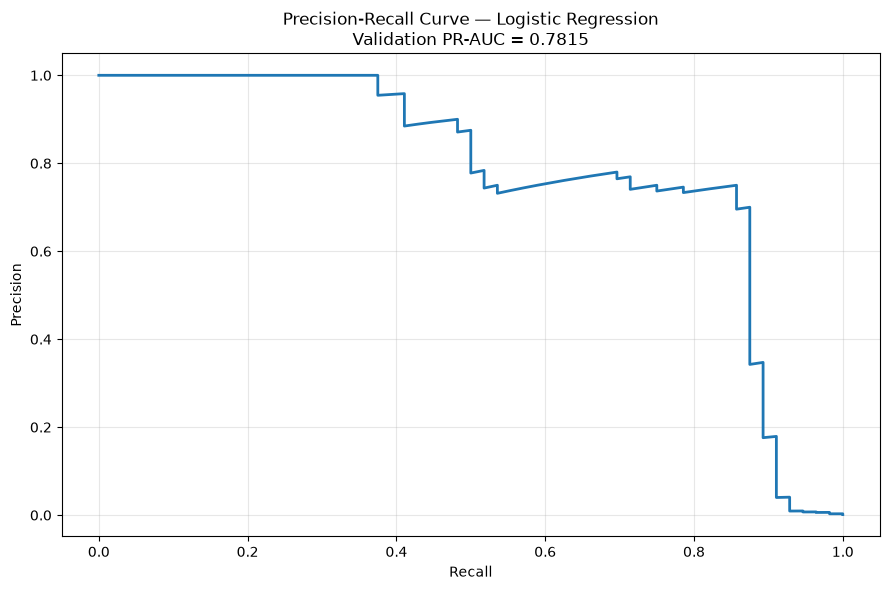

,Model,Validation PR-AUC,Test PR-AUC,Validation ROC-AUC,Test ROC-AUC,Test Precision,Test Recall,Test F1,Test Alerts
0,Logistic Regression,0.781488,0.643561,0.982398,0.964681,0.757576,0.480769,0.588235,33



✓ Baseline results saved.
../reports/baseline_results.csv

PHASE 3 COMPLETE
✓ Logistic regression trained
✓ PR-AUC calculated
✓ ROC-AUC calculated
✓ Precision/Recall/F1 calculated
✓ Confusion matrix calculated
✓ Precision-recall curve generated
✓ Baseline results saved


In [1]:
# ============================================================
# CREDIT CARD FRAUD DETECTION
# PHASE 3 — BASELINE MODEL
# Logistic Regression
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve
)


# ============================================================
# 1. LOAD DATA
# ============================================================

DATA_PATH = Path("../data/creditcard.csv")

df = pd.read_csv(DATA_PATH)

print("=" * 70)
print("DATASET LOADED")
print("=" * 70)

print(f"Shape: {df.shape}")


# ============================================================
# 2. SORT CHRONOLOGICALLY
# ============================================================

df = df.sort_values("Time").reset_index(drop=True)


# ============================================================
# 3. RECREATE TEMPORAL SPLIT
# ============================================================

n = len(df)

train_end = int(n * 0.70)
validation_end = int(n * 0.85)

train = df.iloc[:train_end].copy()
validation = df.iloc[train_end:validation_end].copy()
test = df.iloc[validation_end:].copy()


# ============================================================
# 4. DEFINE FEATURES AND TARGET
# ============================================================

TARGET = "Class"

# We use the original Time and Amount for now.
#
# Time is converted to hours simply to make its scale
# more interpretable.
#
# Amount will be standardized along with Time.

FEATURES = [
    column
    for column in df.columns
    if column not in [TARGET]
]

X_train = train[FEATURES].copy()
y_train = train[TARGET].copy()

X_validation = validation[FEATURES].copy()
y_validation = validation[TARGET].copy()

X_test = test[FEATURES].copy()
y_test = test[TARGET].copy()


# ============================================================
# 5. SCALE FEATURES
# ============================================================

# Logistic regression is sensitive to feature scale.
#
# IMPORTANT:
# The scaler is fitted ONLY on training data.
#
# Validation and test data are transformed using
# parameters learned from training data.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_validation_scaled = scaler.transform(X_validation)

X_test_scaled = scaler.transform(X_test)

print("\n✓ StandardScaler fitted only on training data.")


# ============================================================
# 6. TRAIN BASELINE LOGISTIC REGRESSION
# ============================================================

model = LogisticRegression(
    max_iter=1000,
    class_weight=None,
    random_state=42
)

model.fit(
    X_train_scaled,
    y_train
)

print("✓ Logistic regression trained.")


# ============================================================
# 7. PREDICT PROBABILITIES
# ============================================================

train_prob = model.predict_proba(X_train_scaled)[:, 1]

validation_prob = model.predict_proba(
    X_validation_scaled
)[:, 1]

test_prob = model.predict_proba(
    X_test_scaled
)[:, 1]


# ============================================================
# 8. PR-AUC
# ============================================================

train_pr_auc = average_precision_score(
    y_train,
    train_prob
)

validation_pr_auc = average_precision_score(
    y_validation,
    validation_prob
)

test_pr_auc = average_precision_score(
    y_test,
    test_prob
)

print("\n" + "=" * 70)
print("PR-AUC")
print("=" * 70)

print(f"Train PR-AUC      : {train_pr_auc:.6f}")
print(f"Validation PR-AUC : {validation_pr_auc:.6f}")
print(f"Test PR-AUC       : {test_pr_auc:.6f}")


# ============================================================
# 9. ROC-AUC
# ============================================================

print("\n" + "=" * 70)
print("ROC-AUC")
print("=" * 70)

print(
    f"Validation ROC-AUC : "
    f"{roc_auc_score(y_validation, validation_prob):.6f}"
)

print(
    f"Test ROC-AUC       : "
    f"{roc_auc_score(y_test, test_prob):.6f}"
)


# ============================================================
# 10. THRESHOLD = 0.50
# ============================================================

threshold = 0.50

validation_pred = (
    validation_prob >= threshold
).astype(int)

test_pred = (
    test_prob >= threshold
).astype(int)


# ============================================================
# 11. CLASSIFICATION METRICS
# ============================================================

print("\n" + "=" * 70)
print("VALIDATION PERFORMANCE — THRESHOLD 0.50")
print("=" * 70)

print(
    classification_report(
        y_validation,
        validation_pred,
        digits=4,
        zero_division=0
    )
)

print("\n" + "=" * 70)
print("TEST PERFORMANCE — THRESHOLD 0.50")
print("=" * 70)

print(
    classification_report(
        y_test,
        test_pred,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 12. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    test_pred
)

print("\n" + "=" * 70)
print("TEST CONFUSION MATRIX")
print("=" * 70)

print(cm)

tn, fp, fn, tp = cm.ravel()

print(f"\nTrue Negatives  : {tn:,}")
print(f"False Positives : {fp:,}")
print(f"False Negatives : {fn:,}")
print(f"True Positives  : {tp:,}")


# ============================================================
# 13. PRECISION-RECALL CURVE
# ============================================================

precision, recall, thresholds = precision_recall_curve(
    y_validation,
    validation_prob
)

plt.figure(figsize=(9, 6))

plt.plot(
    recall,
    precision,
    linewidth=2
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    f"Precision-Recall Curve — "
    f"Logistic Regression\n"
    f"Validation PR-AUC = {validation_pr_auc:.4f}"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()


# ============================================================
# 14. BASELINE METRICS TABLE
# ============================================================

baseline_results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Validation PR-AUC": [validation_pr_auc],
    "Test PR-AUC": [test_pr_auc],
    "Validation ROC-AUC": [
        roc_auc_score(
            y_validation,
            validation_prob
        )
    ],
    "Test ROC-AUC": [
        roc_auc_score(
            y_test,
            test_prob
        )
    ],
    "Test Precision": [
        precision_score(
            y_test,
            test_pred,
            zero_division=0
        )
    ],
    "Test Recall": [
        recall_score(
            y_test,
            test_pred,
            zero_division=0
        )
    ],
    "Test F1": [
        f1_score(
            y_test,
            test_pred,
            zero_division=0
        )
    ],
    "Test Alerts": [
        int(test_pred.sum())
    ]
})

display(baseline_results)


# ============================================================
# 15. SAVE BASELINE RESULTS
# ============================================================

baseline_results.to_csv(
    "../reports/baseline_results.csv",
    index=False
)

print("\n✓ Baseline results saved.")
print("../reports/baseline_results.csv")


# ============================================================
# FINAL
# ============================================================

print("\n" + "=" * 70)
print("PHASE 3 COMPLETE")
print("=" * 70)

print("✓ Logistic regression trained")
print("✓ PR-AUC calculated")
print("✓ ROC-AUC calculated")
print("✓ Precision/Recall/F1 calculated")
print("✓ Confusion matrix calculated")
print("✓ Precision-recall curve generated")
print("✓ Baseline results saved")